<a href="https://colab.research.google.com/github/sokrypton/ml4me/blob/main/finetune_esm2_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fine-tuning ESM2 for Protein Binding Prediction**

A lesson in three acts:

| Strategy | What's trainable | Parameters | Risk |
|----------|-----------------|------------|------|
| **Step 1:** Head only | Classification head | ~hundreds | Underfitting |
| **Step 2:** Full fine-tune | Everything | ~8M | Overfitting |
| **Step 3:** LoRA | Adapters + head | ~thousands | Sweet spot |

We'll train all three on the same data and compare loss curves to see the tradeoffs.

Special thanks to [Amelie Schreiber](https://github.com/Amelie-Schreiber/esm2_loras) and [Sergey Ovchinnikov](https://github.com/sokrypton/roscon2024)

---
## Setup

In [1]:
!pip install -q transformers peft accelerate torchao>=0.16.0

In [2]:
model_name = "esm2_t30_150M_UR50D" # @param ["esm2_t33_650M_UR50D", "esm2_t30_150M_UR50D", "esm2_t12_35M_UR50D", "esm2_t6_8M_UR50D"]

In [3]:
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import EsmForTokenClassification, AutoTokenizer
from peft import LoraConfig, get_peft_model

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda:0


---
## Load Data

We use the AF2Bind dataset — per-residue binding labels for proteins.

In [4]:
#@markdown ##Data Loading
batch_size = 32 # @param {"type":"integer"}
max_crop_len = 512 # @param {"type":"integer"}

!wget -qnc https://github.com/sokrypton/ml4me/raw/refs/heads/main/af2bind_data_0.pkl
import pickle
with open("af2bind_data_0.pkl", "rb") as handle:
  DATA = pickle.load(handle)

def pad_sequence(seq, max_len, pad_value=0):
    pad_size = max(0, max_len - len(seq))
    return np.pad(seq, (0, pad_size), 'constant', constant_values=pad_value)[:max_len]

class CustomProteinDataset(Dataset):
    def __init__(self, inputs, attention_masks, outputs, masks, max_crop_len=128):
        self.inputs = inputs
        self.attention_masks = attention_masks
        self.outputs = outputs
        self.masks = masks
        self.max_crop_len = max_crop_len

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_ids = self.inputs[idx]
        attention_mask = self.attention_masks[idx]
        output = self.outputs[idx]
        mask = self.masks[idx]

        true_len = int(np.sum(attention_mask))
        crop_len = min(self.max_crop_len, true_len)

        if true_len > crop_len:
            start_idx = np.random.randint(0, true_len - crop_len + 1)
        else:
            start_idx = 0

        input_ids = input_ids[start_idx:start_idx + crop_len]
        attention_mask = attention_mask[start_idx:start_idx + crop_len].astype(np.float32)
        output = output[start_idx:start_idx + crop_len].astype(np.float32)
        mask = mask[start_idx:start_idx + crop_len].astype(np.float32)

        input_ids = pad_sequence(input_ids, self.max_crop_len)
        attention_mask = pad_sequence(attention_mask, self.max_crop_len)
        output = pad_sequence(output, self.max_crop_len)
        mask = pad_sequence(mask, self.max_crop_len)

        return torch.tensor(input_ids), torch.tensor(attention_mask), torch.tensor(output), torch.tensor(mask)

dataloaders = []
for v in range(3):  # train/test/validation
    dataset = CustomProteinDataset(DATA["inputs"][v], DATA["attention_masks"][v],
                                   DATA["outputs"][v], DATA["masks"][v],
                                   max_crop_len=max_crop_len)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=(v == 0))
    dataloaders.append(dataloader)

train_loader, test_loader, val_loader = dataloaders
print(f"Train: {len(train_loader.dataset)} | Test: {len(test_loader.dataset)} | Val: {len(val_loader.dataset)}")

Train: 582 | Test: 23 | Val: 67


---
## Training Utilities

In [5]:
def compute_loss(logits, labels, mask):
    """Compute masked binary cross-entropy loss."""
    loss = nn.BCEWithLogitsLoss(reduction='none')(logits, labels)
    masked_loss = loss * mask
    return masked_loss.sum() / mask.sum()

def train_one_epoch(model, dataloader, optimizer):
    """Train for one epoch, return average loss."""
    model.train()
    total_loss = 0
    for batch in dataloader:
        inputs, attn_mask, labels, mask = [x.to(DEVICE) for x in batch]
        logits = model(input_ids=inputs, attention_mask=attn_mask).logits.squeeze(-1)
        loss = compute_loss(logits, labels, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

@torch.no_grad()
def validate(model, dataloader):
    """Validate, return average loss."""
    model.eval()
    total_loss = 0
    for batch in dataloader:
        inputs, attn_mask, labels, mask = [x.to(DEVICE) for x in batch]
        logits = model(input_ids=inputs, attention_mask=attn_mask).logits.squeeze(-1)
        total_loss += compute_loss(logits, labels, mask).item()
    return total_loss / len(dataloader)

def train_and_record(model, train_loader, test_loader, num_epochs, lr, label):
    """Train model, return dict of train/test loss curves."""
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    train_losses, test_losses = [], []

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        test_loss = validate(model, test_loader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"  Epoch {epoch+1:2d}/{num_epochs} | Train: {train_loss:.4f} | Test: {test_loss:.4f}")

    return {"train": train_losses, "test": test_losses}

In [6]:
# Training config
num_epochs = 30  # @param {"type":"integer"}
learning_rate = 1e-3  # @param {"type":"number"}

# We'll collect all results here for the final comparison plot
all_results = {}

---
## Step 1: Head Only (Frozen Backbone)

Freeze the entire ESM2 transformer and only train the classification head.
This is fast and cheap, but the model can only learn a linear mapping from
pretrained features — it may **underfit** if those features aren't rich enough
for the task.

In [7]:
# Load fresh model
model_head = EsmForTokenClassification.from_pretrained(
    f"facebook/{model_name}", num_labels=1, hidden_dropout_prob=0.15
).to(DEVICE)

# Freeze backbone — only classifier head remains trainable
for param in model_head.esm.parameters():
    param.requires_grad = False

all_results["Head Only"] = train_and_record(
    model_head, train_loader, test_loader, num_epochs, learning_rate,
    "Step 1: Head Only (frozen backbone)"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmForTokenClassification LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Step 1: Head Only (frozen backbone)
Trainable: 641 / 147,729,242 (0.00%)
  Epoch  1/30 | Train: 0.6561 | Test: 0.7017
  Epoch  2/30 | Train: 0.4177 | Test: 0.6210
  Epoch  3/30 | Train: 0.3434 | Test: 0.5790
  Epoch  4/30 | Train: 0.3252 | Test: 0.5580
  Epoch  5/30 | Train: 0.3239 | Test: 0.5471
  Epoch  6/30 | Train: 0.3172 | Test: 0.5408
  Epoch  7/30 | Train: 0.3192 | Test: 0.5365
  Epoch  8/30 | Train: 0.3211 | Test: 0.5333
  Epoch  9/30 | Train: 0.3174 | Test: 0.5313
  Epoch 10/30 | Train: 0.3149 | Test: 0.5286
  Epoch 11/30 | Train: 0.3145 | Test: 0.5266
  Epoch 12/30 | Train: 0.3199 | Test: 0.5247
  Epoch 13/30 | Train: 0.3118 | Test: 0.5235
  Epoch 14/30 | Train: 0.3152 | Test: 0.5206
  Epoch 15/30 | Train: 0.3152 | Test: 0.5191
  Epoch 16/30 | Train: 0.3153 | Test: 0.5170
  Epoch 17/30 | Train: 0.3122 | Test: 0.5155
  Epoch 18/30 | Train: 0.3119 | Test: 0.5136
  Epoch 19/30 | Train: 0.3147 | Test: 0.5113
  Epoch 20/30 | Train: 0.3098 | Test: 0.5114
  Epoch 21/30 | Train: 0.3

---
## Step 2: Full Fine-tune

Unfreeze everything — the backbone adapts to the task. More expressive, but
with ~8M trainable parameters on a small dataset, watch the gap between
train and test loss grow. That gap is **overfitting**.

In [8]:
# Load fresh model — everything trainable by default
model_full = EsmForTokenClassification.from_pretrained(
    f"facebook/{model_name}", num_labels=1, hidden_dropout_prob=0.15
).to(DEVICE)

all_results["Full Fine-tune"] = train_and_record(
    model_full, train_loader, test_loader, num_epochs, learning_rate,
    "Step 2: Full Fine-tune (all parameters)"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmForTokenClassification LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Step 2: Full Fine-tune (all parameters)
Trainable: 147,729,242 / 147,729,242 (100.00%)
  Epoch  1/30 | Train: 0.3490 | Test: 0.2848
  Epoch  2/30 | Train: 0.3174 | Test: 0.2811
  Epoch  3/30 | Train: 0.3036 | Test: 0.2750
  Epoch  4/30 | Train: 0.2955 | Test: 0.2694
  Epoch  5/30 | Train: 0.2885 | Test: 0.2780
  Epoch  6/30 | Train: 0.2874 | Test: 0.2832
  Epoch  7/30 | Train: 0.2756 | Test: 0.2716
  Epoch  8/30 | Train: 0.2640 | Test: 0.2865
  Epoch  9/30 | Train: 0.2548 | Test: 0.2878
  Epoch 10/30 | Train: 0.2375 | Test: 0.2911
  Epoch 11/30 | Train: 0.2290 | Test: 0.2889
  Epoch 12/30 | Train: 0.2174 | Test: 0.3283
  Epoch 13/30 | Train: 0.2011 | Test: 0.3316
  Epoch 14/30 | Train: 0.1822 | Test: 0.3417
  Epoch 15/30 | Train: 0.1714 | Test: 0.3541
  Epoch 16/30 | Train: 0.1563 | Test: 0.3637
  Epoch 17/30 | Train: 0.1419 | Test: 0.3712
  Epoch 18/30 | Train: 0.1285 | Test: 0.4083
  Epoch 19/30 | Train: 0.1172 | Test: 0.4096
  Epoch 20/30 | Train: 0.1020 | Test: 0.4539
  Epoch 21/3

---
## Step 3: LoRA

Low-Rank Adaptation: inject small trainable matrices into the attention layers.
The backbone stays frozen, but the model can now learn task-specific attention
patterns with far fewer parameters. This is the **sweet spot** — more expressive
than head-only, but regularized enough to avoid overfitting.

In [9]:
# Load fresh model
model_lora = EsmForTokenClassification.from_pretrained(
    f"facebook/{model_name}", num_labels=1, hidden_dropout_prob=0.15
).to(DEVICE)

# Apply LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=["query", "key", "value"],
    lora_dropout=0.15,
    bias="none",
    task_type="TOKEN_CLS",
    modules_to_save=["classifier"],  # also save the head with the adapter
)
model_lora = get_peft_model(model_lora, lora_config)

all_results["LoRA"] = train_and_record(
    model_lora, train_loader, test_loader, num_epochs, learning_rate,
    "Step 3: LoRA (adapters + head)"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmForTokenClassification LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Step 3: LoRA (adapters + head)
Trainable: 461,441 / 148,190,683 (0.31%)
  Epoch  1/30 | Train: 0.4905 | Test: 0.3692
  Epoch  2/30 | Train: 0.3209 | Test: 0.2889
  Epoch  3/30 | Train: 0.3179 | Test: 0.2873
  Epoch  4/30 | Train: 0.3183 | Test: 0.2868
  Epoch  5/30 | Train: 0.3226 | Test: 0.2868
  Epoch  6/30 | Train: 0.3170 | Test: 0.2864
  Epoch  7/30 | Train: 0.3177 | Test: 0.2870
  Epoch  8/30 | Train: 0.3175 | Test: 0.2868
  Epoch  9/30 | Train: 0.3186 | Test: 0.2863
  Epoch 10/30 | Train: 0.3154 | Test: 0.2870
  Epoch 11/30 | Train: 0.3154 | Test: 0.3001
  Epoch 12/30 | Train: 0.3100 | Test: 0.3387
  Epoch 13/30 | Train: 0.3113 | Test: 0.3578
  Epoch 14/30 | Train: 0.3059 | Test: 0.3548
  Epoch 15/30 | Train: 0.3050 | Test: 0.3766
  Epoch 16/30 | Train: 0.3031 | Test: 0.3635
  Epoch 17/30 | Train: 0.3006 | Test: 0.3504
  Epoch 18/30 | Train: 0.2960 | Test: 0.2887
  Epoch 19/30 | Train: 0.2960 | Test: 0.2912
  Epoch 20/30 | Train: 0.2935 | Test: 0.3120
  Epoch 21/30 | Train: 0.29

---
## Comparison

Now let's plot all three strategies side by side.

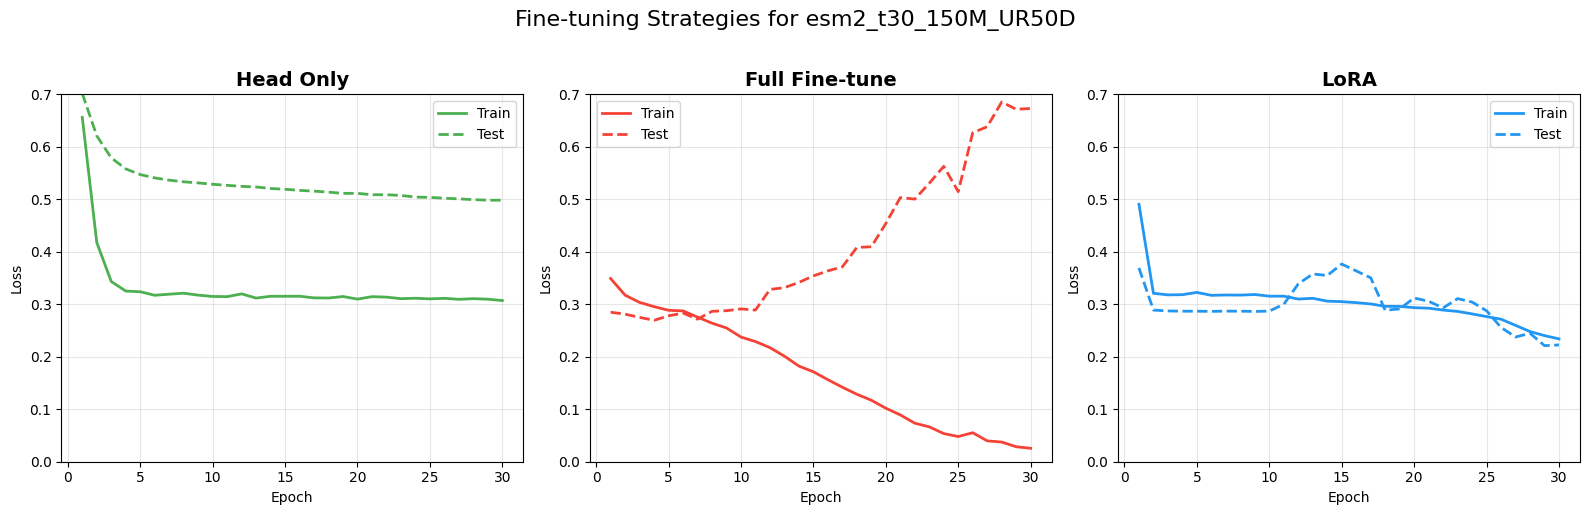

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {"Head Only": "#4CAF50", "Full Fine-tune": "#F44336", "LoRA": "#2196F3"}
epochs = range(1, num_epochs + 1)

# Individual plots
for ax, (name, res) in zip(axes, all_results.items()):
    ax.plot(epochs, res["train"], '-', color=colors[name], label="Train", linewidth=2)
    ax.plot(epochs, res["test"], '--', color=colors[name], label="Test", linewidth=2)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.0,0.7)

plt.suptitle(f"Fine-tuning Strategies for {model_name}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

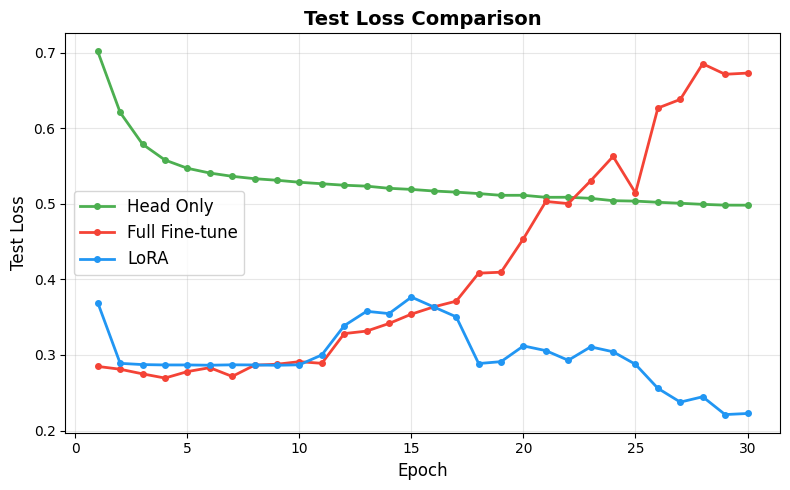

In [11]:
# Overlay: test loss comparison
plt.figure(figsize=(8, 5))
for name, res in all_results.items():
    plt.plot(epochs, res["test"], '-o', color=colors[name], label=name, linewidth=2, markersize=4)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Test Loss", fontsize=12)
plt.title("Test Loss Comparison", fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## What to look for

- **Head Only**: Train and test loss converge together but plateau high → the model
  doesn't have enough capacity to learn the task well. This is **underfitting**.

- **Full Fine-tune**: Train loss drops very low, but test loss starts rising after
  a few epochs → the model memorizes training data instead of generalizing.
  The growing train/test **gap** is the signature of **overfitting**.

- **LoRA**: Train loss drops reasonably, test loss tracks it closely → the low-rank
  constraint acts as implicit regularization, giving us the best of both worlds.

### Key takeaway
LoRA lets the model adapt its attention patterns to the task (unlike head-only)
without the freedom to memorize noise (unlike full fine-tuning). For small
biological datasets, this is usually the right call.

In [12]:
model_full

EsmForTokenClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 640, padding_idx=1)
      (dropout): Dropout(p=0.15, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-29): 30 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=640, out_features=640, bias=True)
              (key): Linear(in_features=640, out_features=640, bias=True)
              (value): Linear(in_features=640, out_features=640, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=640, out_features=640, bias=True)
              (dropout): Dropout(p=0.15, inplace=False)
            )
            (LayerNorm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_feature

In [13]:
model_lora

PeftModelForTokenClassification(
  (base_model): LoraModel(
    (model): EsmForTokenClassification(
      (esm): EsmModel(
        (embeddings): EsmEmbeddings(
          (word_embeddings): Embedding(33, 640, padding_idx=1)
          (dropout): Dropout(p=0.15, inplace=False)
        )
        (encoder): EsmEncoder(
          (layer): ModuleList(
            (0-29): 30 x EsmLayer(
              (attention): EsmAttention(
                (self): EsmSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=640, out_features=640, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.15, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=640, out_features=4, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=4, out_features=640, bias=False